# JobMatch AI — Notebook 01: EDA (Análise Exploratória de Dados)

**Projeto:** JobMatch AI — Sistema de Matching Currículo-Vaga com NLP/Deep Learning
**Autor:** Eduardo Matos
**Etapa:** Análise Exploratória do dataset de vagas coletadas manualmente

Este notebook faz a análise exploratória das 15 vagas reais coletadas do LinkedIn/Gupy,
antes de avançarmos para tokenização e fine-tuning do BERTimbau.

**Objetivo da EDA em NLP:** entender distribuição de tamanho de texto, frequência de
palavras por classe, e verificar se existe sinal semântico real separando vagas de
"bom fit" e "mau fit" — isso valida se o dataset tem informação suficiente para o
modelo aprender.


## 1. Setup do ambiente

Instalando bibliotecas (o ambiente do Colab não vem com tudo pré-instalado).

In [1]:
!pip install wordcloud -q


## 2. Montando o Google Drive

Guarde o arquivo `vagas_clean.csv` numa pasta do seu Drive (ex: `MyDrive/jobmatch-ai/data/`)
antes de rodar a célula abaixo.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Ajuste esse caminho para onde você salvou o CSV no seu Drive
CAMINHO_CSV = '/content/drive/MyDrive/jobmatch-ai/processed/vagas_clean.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Carregando o dataset

In [5]:
import pandas as pd

df = pd.read_csv(CAMINHO_CSV)
print("Shape:", df.shape)
df.head()


Shape: (15, 16)


,id,fonte,titulo,empresa,descricao,requisitos,senioridade,area,remoto,fit_percentual,url,data_coleta,area_padronizada,tam_caracteres,tam_palavras,categoria_fit
0,1,LinkedIn,Fraud Data Analyst - Pleno,Cora,"Das 21 milhões de empresas do Brasil, 93% são ...",Fluência em SQL e autonomia no uso de Python o...,pleno,Ciencia de Dados,sim,75,https://www.linkedin.com/jobs/collections/reco...,07/07/2026,Ciencia de Dados,452,80,Alto (>=60)
1,2,LinkedIn,Data science,hire fide,"We are hiring for one of our clients, seeking ...","• Proficiency in Python, including libraries s...",junior,Ciencia de Dados,sim,60,https://www.linkedin.com/jobs/search/?alertAct...,05/07/2026,Ciencia de Dados,282,43,Alto (>=60)
2,3,LinkedIn,Pessoa Cientista de Dados - Vaga afirmativa pa...,Artefact,Nós da Artefact LatAm acreditamos e vivemos um...,Ter cursado um curso de graduação em ciência d...,junior,Ciencia de Dados,sim,80,https://www.linkedin.com/jobs/collections/reco...,04/07/2026,Ciencia de Dados,489,74,Alto (>=60)
3,4,LinkedIn,Cientista de Dados - Trabalho Remoto,BairesDev,"Há mais de 15 anos, a BairesDev® é líder em pr...",- 3+ anos de experiência na aplicação de técni...,junior,Ciencia de Dados,sim,60,https://www.linkedin.com/jobs/collections/reco...,05/07/2026,Ciencia de Dados,1081,161,Alto (>=60)
4,5,LinkedIn,ciencia de dados pricing,pricing,A RD Saúde é uma empresa líder no mercado bras...,• Ensino superior completo ou em andamento nas...,junior,Ciencia de Dados,sim,75,https://rdsaude-corporativo.gupy.io/jobs/11578256,05/07/2026,Ciencia de Dados,524,91,Alto (>=60)


## 4. Estatísticas de tamanho de texto

Em NLP, o tamanho do texto (em caracteres/palavras) importa porque define parâmetros
do tokenizer depois (`max_length`, truncation, padding).

In [6]:
df['tam_caracteres'] = df['descricao'].str.len()
df['tam_palavras'] = df['descricao'].str.split().str.len()

def categoria_fit(x):
    if x >= 60:
        return 'Alto (>=60)'
    elif x >= 30:
        return 'Médio (30-59)'
    else:
        return 'Baixo (<30)'

df['categoria_fit'] = df['fit_percentual'].apply(categoria_fit)

print("=== Estatística geral de tamanho ===")
print(df[['tam_caracteres', 'tam_palavras']].describe())

print("\n=== Tamanho médio por categoria de fit ===")
print(df.groupby('categoria_fit')[['tam_caracteres', 'tam_palavras']].mean().round(0))

print("\n=== Contagem de vagas por categoria de fit ===")
print(df['categoria_fit'].value_counts())


=== Estatística geral de tamanho ===
       tam_caracteres  tam_palavras
count       15.000000      15.00000
mean       508.333333      78.40000
std        243.876921      37.27274
min         31.000000       5.00000
25%        373.000000      55.50000
50%        485.000000      80.00000
75%        611.500000      94.50000
max       1081.000000     161.00000

=== Tamanho médio por categoria de fit ===
               tam_caracteres  tam_palavras
categoria_fit                              
Alto (>=60)             534.0          84.0
Baixo (<30)             378.0          54.0
Médio (30-59)           778.0         115.0

=== Contagem de vagas por categoria de fit ===
categoria_fit
Alto (>=60)      10
Baixo (<30)       4
Médio (30-59)     1
Name: count, dtype: int64


## 5. Distribuição visual do `fit_percentual`

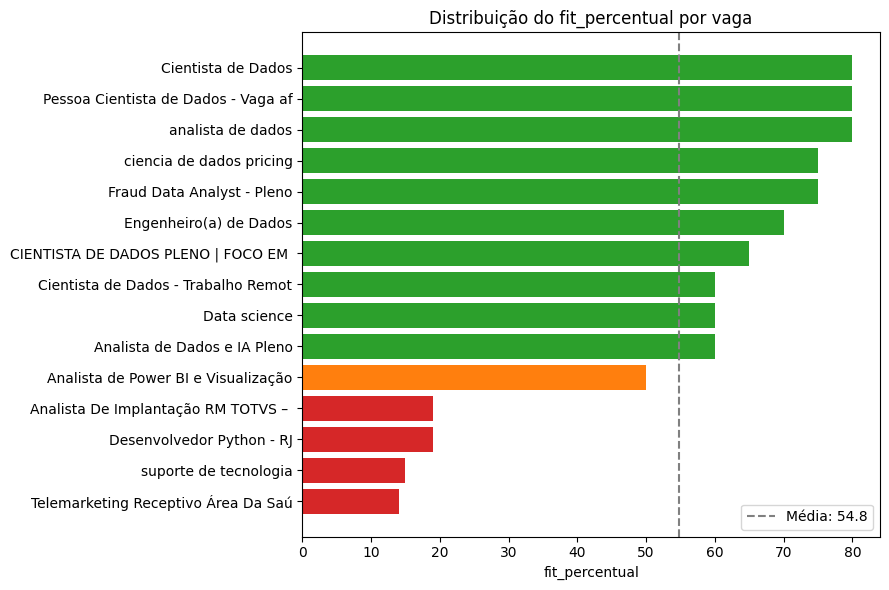

In [7]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values('fit_percentual')
cores = ['#d62728' if x < 30 else '#ff7f0e' if x < 60 else '#2ca02c' for x in df_sorted['fit_percentual']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(df_sorted['titulo'].str[:35], df_sorted['fit_percentual'], color=cores)
ax.set_xlabel('fit_percentual')
ax.set_title('Distribuição do fit_percentual por vaga')
ax.axvline(df['fit_percentual'].mean(), color='gray', linestyle='--',
           label=f"Média: {df['fit_percentual'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Frequência de palavras por classe de fit

Aqui verificamos se existe diferença real de vocabulário entre vagas de fit alto e
fit baixo — esse é o teste mais importante da EDA: **se o vocabulário não muda entre
classes, o modelo não vai ter sinal pra aprender.**

Usamos uma lista manual de stopwords em português (palavras sem carga semântica, tipo
"de", "para", "com").

In [8]:
import re
from collections import Counter

stopwords_pt = set("""
a as o os um uma uns umas de do da dos das em no na nos nas por para com sem sob sobre
que se e ou mas como mais menos muito pouco quando onde qual quem cujo cuja
é são foi foram ser estar tem têm ter sua seu suas seus este esta estes estas isso isto
ao aos à às pelo pela pelos pelas entre até desde após antes durante
nossa nosso nossos nossas você voce vocês voces
não sim já também ainda apenas todo toda todos todas outro outra outros outras
""".split())

def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-zà-ú\s]', ' ', texto)
    palavras = texto.split()
    return [p for p in palavras if p not in stopwords_pt and len(p) > 2]

alto = df[df['fit_percentual'] >= 60]['descricao'].apply(limpar_texto).sum()
baixo = df[df['fit_percentual'] < 30]['descricao'].apply(limpar_texto).sum()

print("=== TOP 15 palavras - Vagas de FIT ALTO (>=60) ===")
for palavra, freq in Counter(alto).most_common(15):
    print(f"{palavra}: {freq}")

print("\n=== TOP 15 palavras - Vagas de FIT BAIXO (<30) ===")
for palavra, freq in Counter(baixo).most_common(15):
    print(f"{palavra}: {freq}")


=== TOP 15 palavras - Vagas de FIT ALTO (>=60) ===
dados: 11
pessoas: 6
temos: 5
soluções: 5
dia: 4
negócios: 3
país: 3
clientes: 3
data: 3
ambiente: 3
compromisso: 3
bairesdev: 3
líder: 3
projetos: 3
equipe: 3

=== TOP 15 palavras - Vagas de FIT BAIXO (<30) ===
experiência: 3
implantação: 3
sustentação: 3
módulo: 3
aprovações: 3
atendimento: 3
profissional: 2
parametrização: 2
taa: 2
atuar: 2
pessoas: 2
estamos: 2
busca: 2
suporte: 2
soluções: 2


## 7. Nuvem de palavras comparativa (visual)

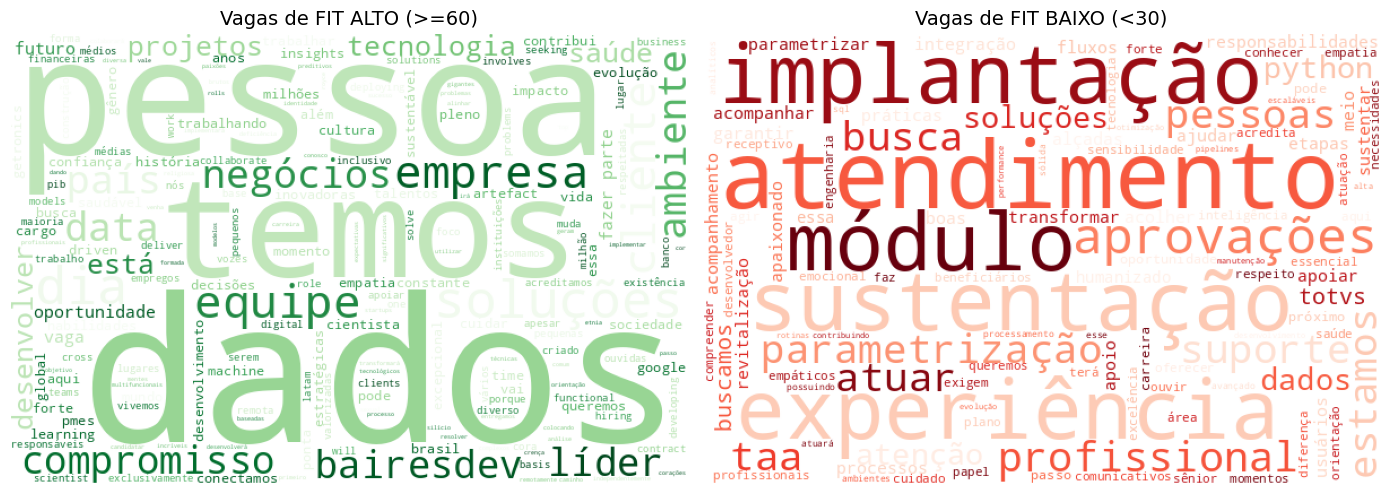

In [9]:
from wordcloud import WordCloud

def limpar_para_wordcloud(texto):
    return ' '.join(limpar_texto(texto))

texto_alto = ' '.join(df[df['fit_percentual'] >= 60]['descricao'].apply(limpar_para_wordcloud))
texto_baixo = ' '.join(df[df['fit_percentual'] < 30]['descricao'].apply(limpar_para_wordcloud))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wc_alto = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(texto_alto)
axes[0].imshow(wc_alto)
axes[0].set_title('Vagas de FIT ALTO (>=60)', fontsize=14)
axes[0].axis('off')

wc_baixo = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(texto_baixo)
axes[1].imshow(wc_baixo)
axes[1].set_title('Vagas de FIT BAIXO (<30)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/jobmatch-ai/notebooks/wordcloud_comparativo.png', dpi=120)
plt.show()


## 8. Conclusões da EDA

- Tamanho de texto varia de 31 a 1081 caracteres (5 a 161 palavras),
  com média de 508 caracteres (~78 palavras)
  → decisão de max_length no tokenizer: como o BERTimbau aceita até 512
  tokens, boa parte das vagas cabe inteira, mas as mais longas (até 1081
  caracteres) provavelmente serão truncadas

- Categoria de fit sub-representada: Médio (30-59), com apenas 1 vaga
  (contra 10 de fit Alto e 4 de fit Baixo)
  → considerar coletar mais vagas nessa faixa numa próxima rodada, para
  balancear melhor o dataset antes do fine-tuning

- Palavras que mais diferenciam fit alto vs baixo:
  vagas de fit alto concentram termos como "dados", "soluções", "negócios",
  "projetos" (vocabulário técnico/DS); vagas de fit baixo concentram
  "implantação", "sustentação", "módulo", "atendimento" (vocabulário
  administrativo/suporte) — separação clara de domínio, bom sinal para o
  modelo aprender

- Próximo passo: tokenização real com BERTimbau
